# Exploratory Data Analysis — Multi-View Pig Posture Recognition

**Projekt:** Deep Learning in der Präzisions-Nutztierhaltung (PLF)  
**Datensatz:** Michigan State University — Kaggle Competition  
**Metrik:** Macro-averaged F1-Score

### Inhalt
1. Datensatz-Übersicht & Grundstatistiken
2. Klassenverteilung & Imbalance-Analyse
3. Beispielbilder pro Klasse (cam1 vs. cam2)
4. Bounding Box Analyse
5. Kameraverteilung & Distribution Shift
6. Zusammenfassung der Erkenntnisse

In [1]:
import os
import json
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import seaborn as sns
from PIL import Image

sns.set_theme(style="whitegrid")

DATA_DIR   = "/datasets/multi-view-pig-posture-recognition/"
DIR_TRAIN1 = os.path.join(DATA_DIR, "train1_images")
DIR_TRAIN2 = os.path.join(DATA_DIR, "train2_images")
DIR_TEST   = os.path.join(DATA_DIR, "test_images")

CLASS_NAMES = {
    0: "Lateral_lying_left",
    1: "Lateral_lying_right",
    2: "Sitting",
    3: "Standing",
    4: "Sternal_lying"
}

def parse_bbox(x):
    if isinstance(x, str):
        try:
            return json.loads(x)
        except:
            return [float(i) for i in x.replace("[", "").replace("]", "").split(",")]
    return x

def extract_camera(image_id):
    parts = os.path.basename(str(image_id)).replace("-", "_").split("_")
    for part in parts:
        if part.lower().startswith("cam"):
            return part.lower()
    return "unknown"

train1_df = pd.read_csv(os.path.join(DATA_DIR, "train1.csv"))
train2_df = pd.read_csv(os.path.join(DATA_DIR, "train2.csv"))
test_df   = pd.read_csv(os.path.join(DATA_DIR, "test.csv"))

for df in [train1_df, train2_df, test_df]:
    df["bbox"]   = df["bbox"].apply(parse_bbox)
    df["camera"] = df["image_id"].apply(extract_camera)

print(f"Train1: {len(train1_df):>6} Samples | {train1_df['image_id'].nunique()} Bilder")
print(f"Train2: {len(train2_df):>6} Samples | {train2_df['image_id'].nunique()} Bilder")
print(f"Test:   {len(test_df):>6} Samples | {test_df['image_id'].nunique()} Bilder")

<jemalloc>: Unsupported system page size


Train1:  22934 Samples | 3090 Bilder
Train2:  23450 Samples | 3150 Bilder
Test:    11708 Samples | 1350 Bilder


## 1. Datensatz-Übersicht & Grundstatistiken

In [2]:
stats = pd.DataFrame({
    "Datensatz":              ["Train1", "Train2", "Test"],
    "Samples (Instanzen)":    [len(train1_df), len(train2_df), len(test_df)],
    "Eindeutige Bilder":      [train1_df["image_id"].nunique(), train2_df["image_id"].nunique(), test_df["image_id"].nunique()],
    "Instanzen pro Bild (Ø)": [
        round(len(train1_df) / train1_df["image_id"].nunique(), 2),
        round(len(train2_df) / train2_df["image_id"].nunique(), 2),
        round(len(test_df)   / test_df["image_id"].nunique(), 2)
    ],
    "Häufigste Auflösung":    [
        f"{train1_df['width'].mode()[0]}×{train1_df['height'].mode()[0]}",
        f"{train2_df['width'].mode()[0]}×{train2_df['height'].mode()[0]}",
        f"{test_df['width'].mode()[0]}×{test_df['height'].mode()[0]}"
    ],
    "Kameras":                [
        ", ".join(sorted(train1_df["camera"].unique())),
        ", ".join(sorted(train2_df["camera"].unique())),
        ", ".join(sorted(test_df["camera"].unique()))
    ]
})
print(stats.to_string(index=False))

Datensatz  Samples (Instanzen)  Eindeutige Bilder  Instanzen pro Bild (Ø) Häufigste Auflösung    Kameras
   Train1                22934               3090                    7.42            1280×720 cam1, cam2
   Train2                23450               3150                    7.44            1280×720 cam1, cam2
     Test                11708               1350                    8.67            1280×720 cam1, cam2


## 2. Klassenverteilung & Imbalance-Analyse

In [3]:
t1_counts = train1_df["class_id"].value_counts().sort_index()
t2_counts = train2_df["class_id"].value_counts().sort_index()
ratio_t1  = t1_counts.max() / t1_counts.min()
ratio_t2  = t2_counts.max() / t2_counts.min()

imbalance_df = pd.DataFrame({
    "Klasse":      [f"{i}: {CLASS_NAMES[i]}" for i in range(5)],
    "Train1 Abs.": t1_counts.values,
    "Train1 %":    (t1_counts.values / len(train1_df) * 100).round(1),
    "Train2 Abs.": t2_counts.values,
    "Train2 %":    (t2_counts.values / len(train2_df) * 100).round(1),
})
print(imbalance_df.to_string(index=False))
print(f"\nImbalance-Ratio Train1: {ratio_t1:.1f}x  (Klasse {t1_counts.idxmax()} vs. Klasse {t1_counts.idxmin()})")
print(f"Imbalance-Ratio Train2: {ratio_t2:.1f}x  (Klasse {t2_counts.idxmax()} vs. Klasse {t2_counts.idxmin()})")
print(f"\n→ Klasse 2 (Sitting) ist ~14x seltener als Klasse 3 (Standing)")
print(f"→ Kritisch für Macro F1: alle Klassen gleich gewichtet, auch seltene!")

                Klasse  Train1 Abs.  Train1 %  Train2 Abs.  Train2 %
 0: Lateral_lying_left         3053      13.3         3083      13.1
1: Lateral_lying_right         3376      14.7         3435      14.6
            2: Sitting          680       3.0          695       3.0
           3: Standing         9617      41.9         9928      42.3
      4: Sternal_lying         6208      27.1         6309      26.9

Imbalance-Ratio Train1: 14.1x  (Klasse 3 vs. Klasse 2)
Imbalance-Ratio Train2: 14.3x  (Klasse 3 vs. Klasse 2)

→ Klasse 2 (Sitting) ist ~14x seltener als Klasse 3 (Standing)
→ Kritisch für Macro F1: alle Klassen gleich gewichtet, auch seltene!


Task was destroyed but it is pending!
task: <Task pending name='Task-51' coro=<_async_in_context.<locals>.run_in_context_pre311() running at /opt/conda/envs/torch/lib/python3.10/site-packages/ipykernel/utils.py:76> cb=[ZMQStream._run_callback.<locals>._log_error() at /opt/conda/envs/torch/lib/python3.10/site-packages/zmq/eventloop/zmqstream.py:563]>
/opt/conda/envs/torch/lib/python3.10/asyncio/base_events.py:671: RuntimeWarning: coroutine '_async_in_context.<locals>.run_in_context_pre311' was never awaited
  self._ready.clear()


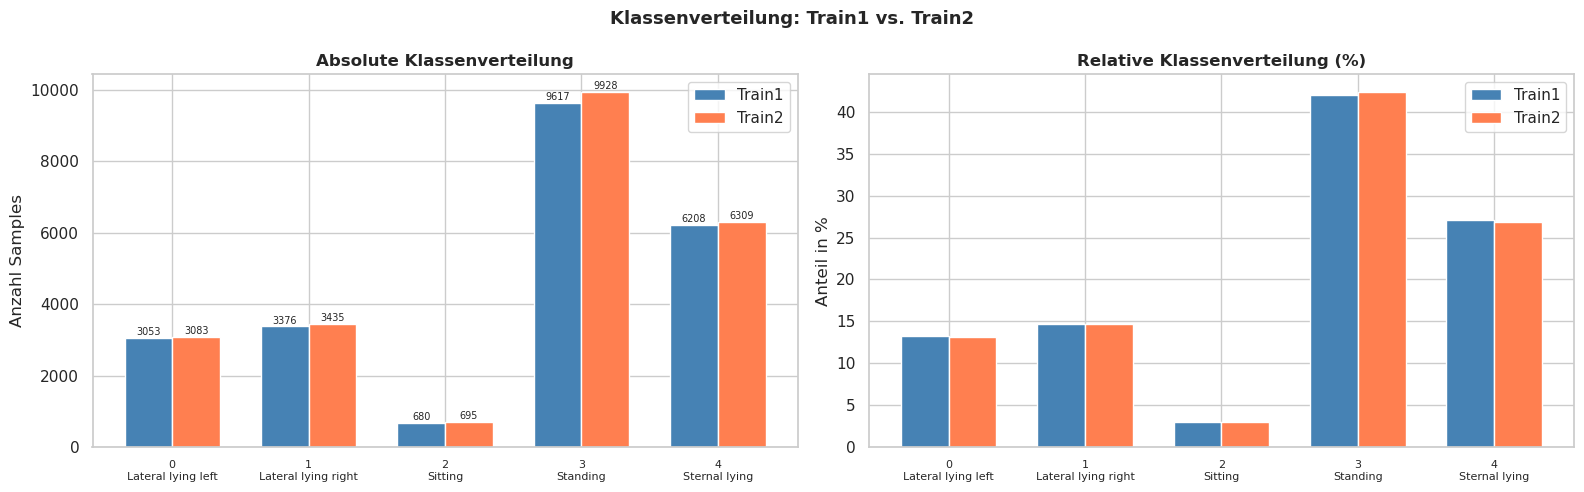

In [4]:
x     = np.arange(5)
width = 0.35
labels_short = [f"{i}\n{CLASS_NAMES[i].replace('_', ' ')}" for i in range(5)]

fig, axes = plt.subplots(1, 2, figsize=(16, 5))

# Absolut
b1 = axes[0].bar(x - width/2, t1_counts.values, width, label="Train1", color="steelblue")
b2 = axes[0].bar(x + width/2, t2_counts.values, width, label="Train2", color="coral")
axes[0].set_xticks(x)
axes[0].set_xticklabels(labels_short, fontsize=8)
axes[0].set_title("Absolute Klassenverteilung", fontweight="bold")
axes[0].set_ylabel("Anzahl Samples")
axes[0].legend()
for i, (v1, v2) in enumerate(zip(t1_counts.values, t2_counts.values)):
    axes[0].text(i - width/2, v1 + 80, str(v1), ha="center", fontsize=7)
    axes[0].text(i + width/2, v2 + 80, str(v2), ha="center", fontsize=7)

# Relativ
axes[1].bar(x - width/2, t1_counts.values / len(train1_df) * 100, width, label="Train1", color="steelblue")
axes[1].bar(x + width/2, t2_counts.values / len(train2_df) * 100, width, label="Train2", color="coral")
axes[1].set_xticks(x)
axes[1].set_xticklabels(labels_short, fontsize=8)
axes[1].set_title("Relative Klassenverteilung (%)", fontweight="bold")
axes[1].set_ylabel("Anteil in %")
axes[1].legend()

plt.suptitle("Klassenverteilung: Train1 vs. Train2", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

## 3. Beispielbilder pro Klasse — cam1 vs. cam2

Visuelle Darstellung des Distribution Shifts: gleiche Klasse, unterschiedliche Kamera.

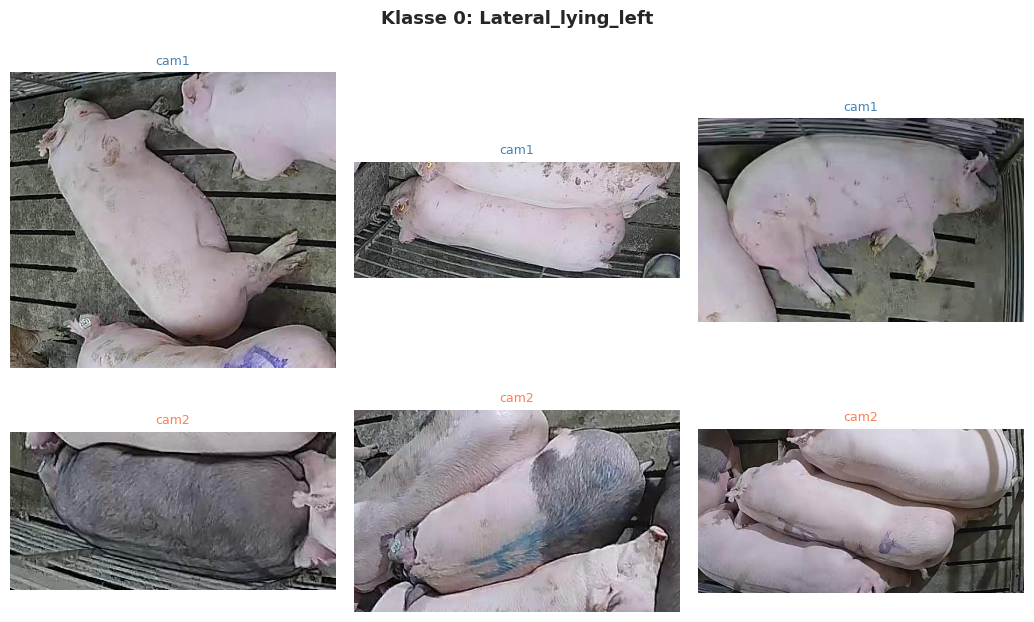

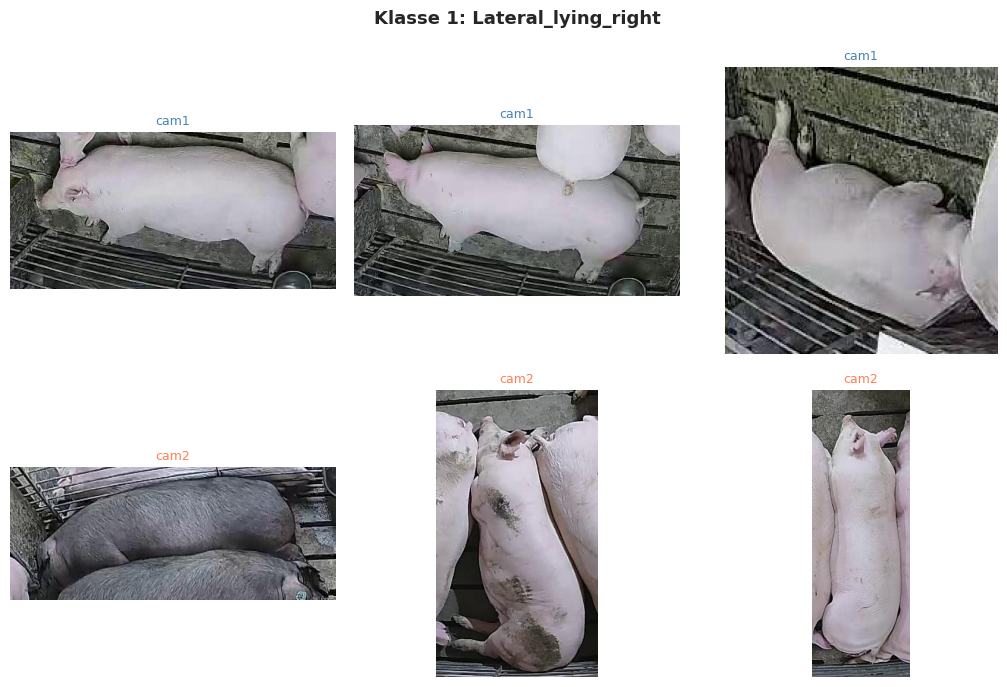

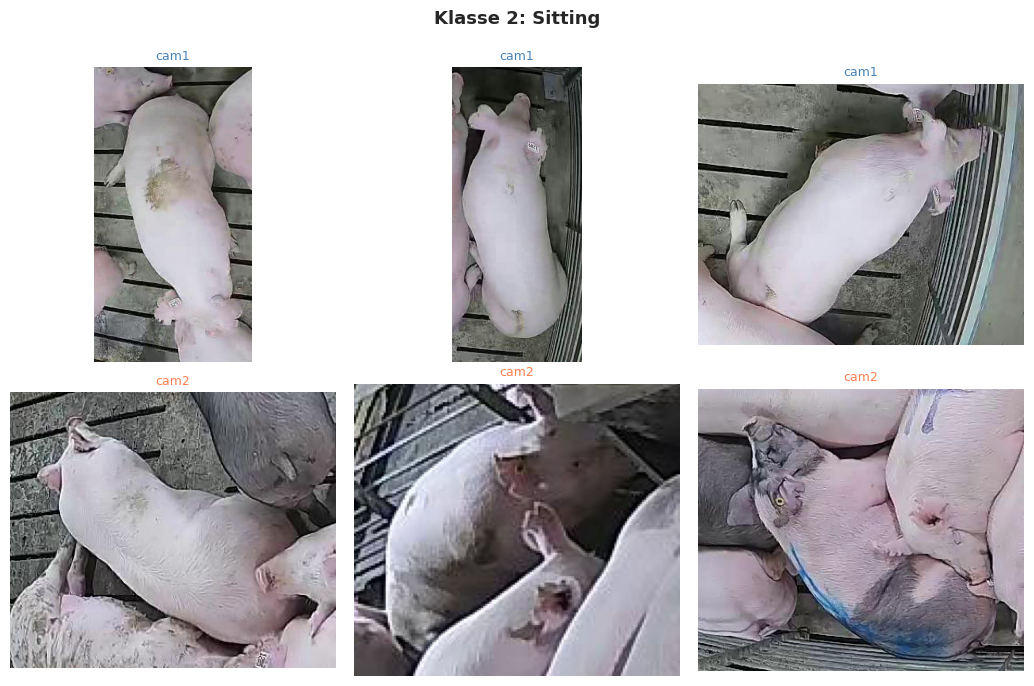

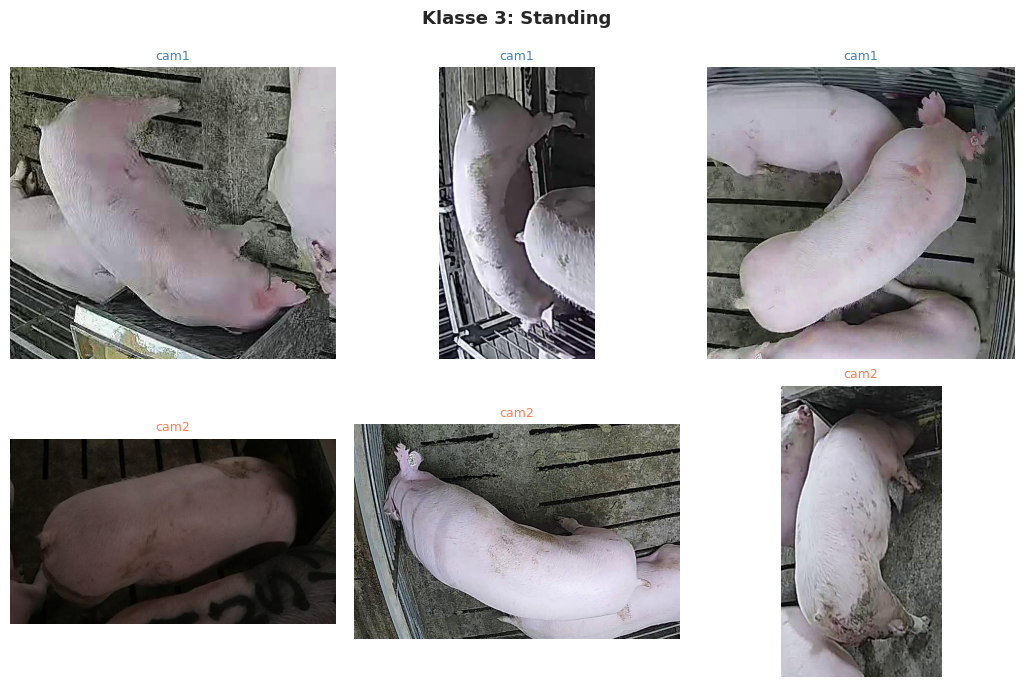

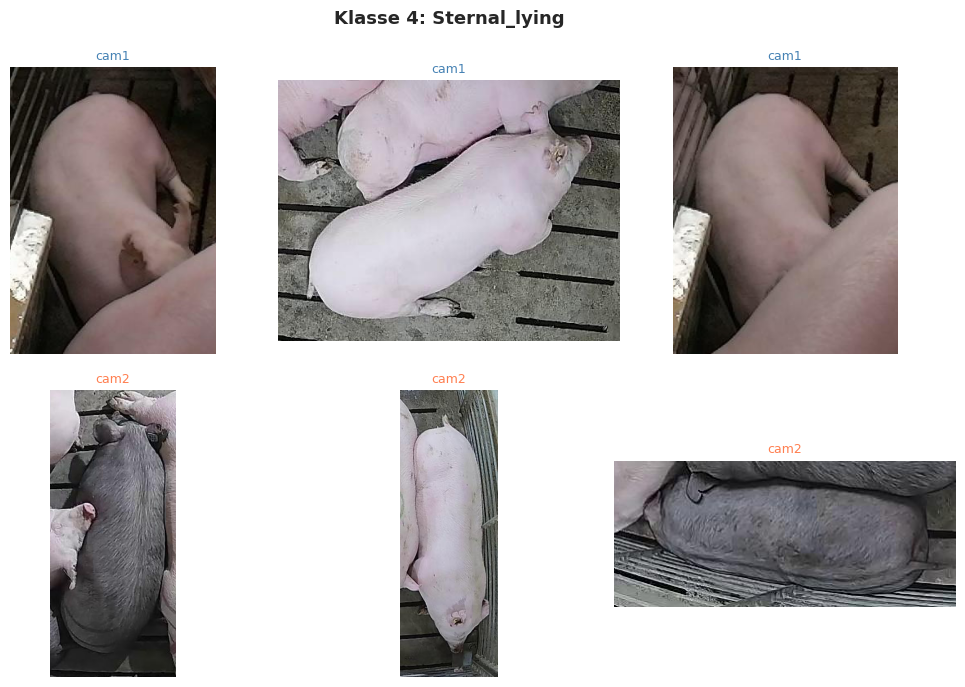

In [5]:
def crop_pig(image, bbox, pad=0.1):
    x, y, w, h  = bbox
    img_w, img_h = image.size
    x1 = max(0, int(x - w * pad))
    y1 = max(0, int(y - h * pad))
    x2 = min(img_w, int(x + w + w * pad))
    y2 = min(img_h, int(y + h + h * pad))
    return image.crop((x1, y1, x2, y2))

def show_class_grid_per_camera(df, img_dir, class_id, num_per_cam=3):
    cam1_rows = df[(df["class_id"] == class_id) & (df["camera"] == "cam1")].sample(n=num_per_cam, random_state=42)
    cam2_rows = df[(df["class_id"] == class_id) & (df["camera"] == "cam2")].sample(n=num_per_cam, random_state=42)

    fig, axes = plt.subplots(2, num_per_cam, figsize=(num_per_cam * 3.5, 7))
    fig.suptitle(f"Klasse {class_id}: {CLASS_NAMES[class_id]}", fontsize=13, fontweight="bold")

    for col, (_, row) in enumerate(cam1_rows.iterrows()):
        img = Image.open(os.path.join(img_dir, row["image_id"])).convert("RGB")
        img = crop_pig(img, row["bbox"])
        axes[0, col].imshow(img)
        axes[0, col].axis("off")
        if col == 0:
            axes[0, col].set_ylabel("cam1", fontsize=11, fontweight="bold")
        axes[0, col].set_title("cam1", fontsize=9, color="steelblue")

    for col, (_, row) in enumerate(cam2_rows.iterrows()):
        img = Image.open(os.path.join(img_dir, row["image_id"])).convert("RGB")
        img = crop_pig(img, row["bbox"])
        axes[1, col].imshow(img)
        axes[1, col].axis("off")
        axes[1, col].set_title("cam2", fontsize=9, color="coral")

    plt.tight_layout()
    plt.show()

# Alle 5 Klassen anzeigen
for c in range(5):
    show_class_grid_per_camera(train2_df, DIR_TRAIN2, c, num_per_cam=3)

## 4. Bounding Box Analyse

Datensatz  Breite Ø (px)  Höhe Ø (px)  Aspect Ratio Ø  Norm. Fläche Ø (%)
   Train1          298.2        294.7           1.173               10.23
   Train2          300.0        296.0           1.174               10.35
     Test          227.9        226.4           1.143                5.72


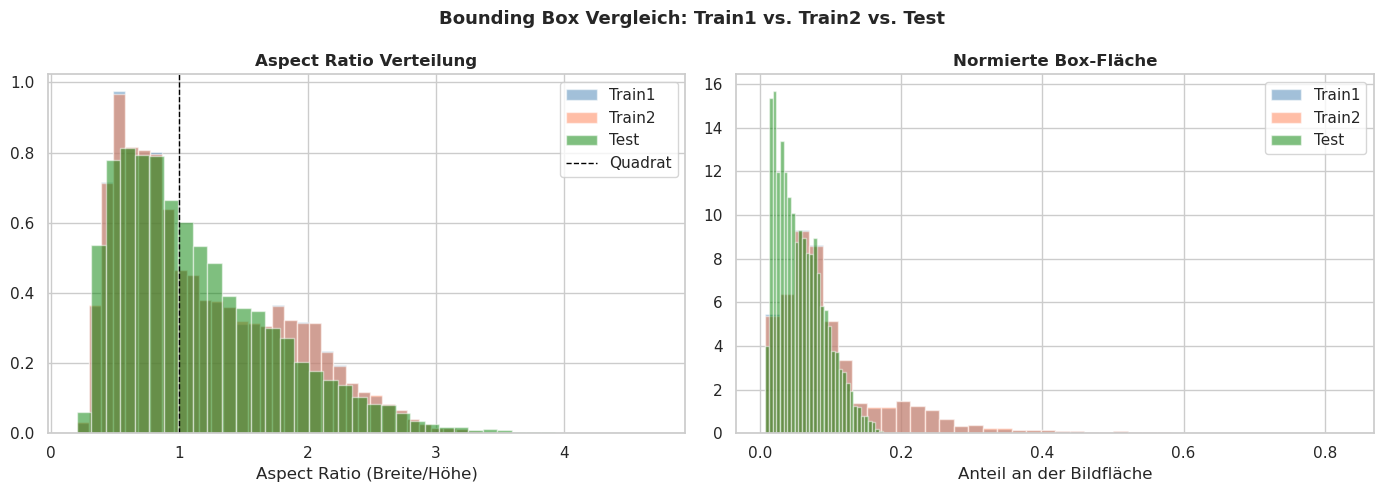

In [6]:
def bbox_features(df, norm_w, norm_h):
    bboxes = pd.DataFrame(df["bbox"].tolist(), columns=["x", "y", "w", "h"])
    bboxes["aspect_ratio"] = bboxes["w"] / bboxes["h"]
    bboxes["area_norm"]    = (bboxes["w"] * bboxes["h"]) / (norm_w * norm_h)
    return bboxes

bb1 = bbox_features(train1_df, train1_df["width"].mode()[0], train1_df["height"].mode()[0])
bb2 = bbox_features(train2_df, train2_df["width"].mode()[0], train2_df["height"].mode()[0])
bbt = bbox_features(test_df,   test_df["width"].mode()[0],   test_df["height"].mode()[0])

bbox_compare = pd.DataFrame({
    "Datensatz":           ["Train1", "Train2", "Test"],
    "Breite Ø (px)":       [bb1["w"].mean().round(1), bb2["w"].mean().round(1), bbt["w"].mean().round(1)],
    "Höhe Ø (px)":         [bb1["h"].mean().round(1), bb2["h"].mean().round(1), bbt["h"].mean().round(1)],
    "Aspect Ratio Ø":      [bb1["aspect_ratio"].mean().round(3), bb2["aspect_ratio"].mean().round(3), bbt["aspect_ratio"].mean().round(3)],
    "Norm. Fläche Ø (%)":  [round(bb1["area_norm"].mean()*100,2), round(bb2["area_norm"].mean()*100,2), round(bbt["area_norm"].mean()*100,2)],
})
print(bbox_compare.to_string(index=False))

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
for data, label, color in [(bb1, "Train1", "steelblue"), (bb2, "Train2", "coral"), (bbt, "Test", "green")]:
    axes[0].hist(data["aspect_ratio"], bins=40, alpha=0.5, label=label, color=color, density=True)
    axes[1].hist(data["area_norm"],    bins=40, alpha=0.5, label=label, color=color, density=True)

axes[0].axvline(1, color="black", linestyle="--", linewidth=1, label="Quadrat")
axes[0].set_title("Aspect Ratio Verteilung", fontweight="bold")
axes[0].set_xlabel("Aspect Ratio (Breite/Höhe)")
axes[0].legend()

axes[1].set_title("Normierte Box-Fläche", fontweight="bold")
axes[1].set_xlabel("Anteil an der Bildfläche")
axes[1].legend()

plt.suptitle("Bounding Box Vergleich: Train1 vs. Train2 vs. Test", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

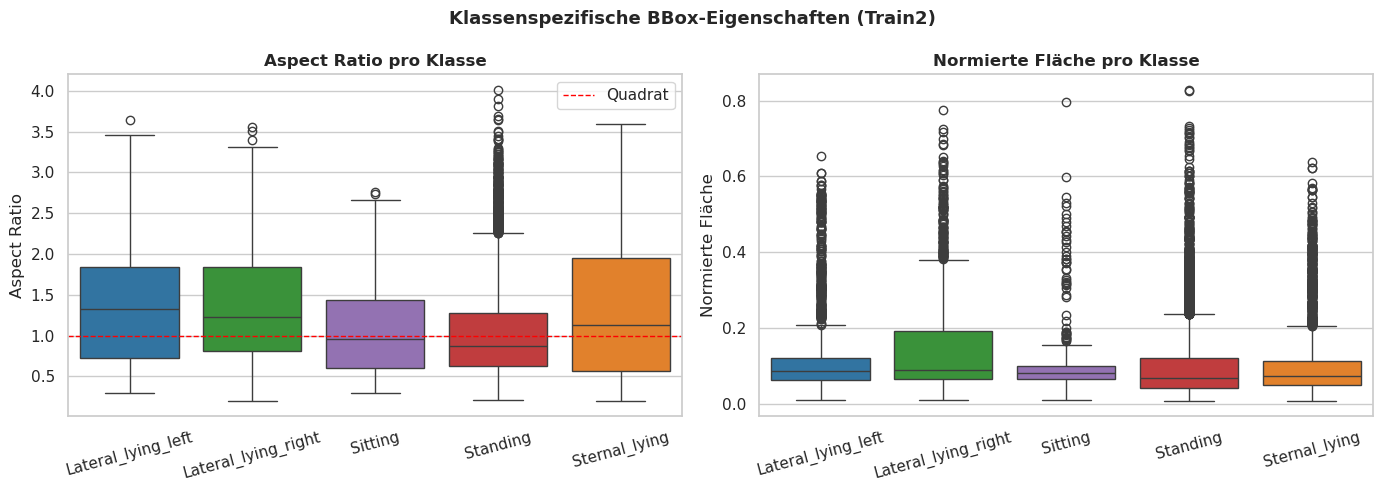

Mittlere Aspect Ratio pro Klasse:
class_name
Lateral_lying_right    1.342
Lateral_lying_left     1.337
Sternal_lying          1.260
Sitting                1.069
Standing               1.018


In [7]:
# Aspect Ratio pro Klasse — Haltungen haben unterschiedliche geometrische Formen
bb2["class_id"]   = train2_df["class_id"].values
bb2["class_name"] = bb2["class_id"].map(CLASS_NAMES)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))

order = [CLASS_NAMES[i] for i in range(5)]
sns.boxplot(data=bb2, x="class_name", y="aspect_ratio", ax=axes[0], order=order,
            hue="class_name", palette="tab10", legend=False)
axes[0].axhline(1, color="red", linestyle="--", linewidth=1, label="Quadrat")
axes[0].set_title("Aspect Ratio pro Klasse", fontweight="bold")
axes[0].set_xlabel("")
axes[0].set_ylabel("Aspect Ratio")
axes[0].tick_params(axis="x", rotation=15)
axes[0].legend()

sns.boxplot(data=bb2, x="class_name", y="area_norm", ax=axes[1], order=order,
            hue="class_name", palette="tab10", legend=False)
axes[1].set_title("Normierte Fläche pro Klasse", fontweight="bold")
axes[1].set_xlabel("")
axes[1].set_ylabel("Normierte Fläche")
axes[1].tick_params(axis="x", rotation=15)

plt.suptitle("Klassenspezifische BBox-Eigenschaften (Train2)", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("Mittlere Aspect Ratio pro Klasse:")
print(bb2.groupby("class_name")["aspect_ratio"].mean().round(3).sort_values(ascending=False).to_string())

## 5. Kameraverteilung & Distribution Shift

=== Kamera-Verteilung ===

Train1:
  cam1: 13252 Samples (57.8%)
  cam2:  9682 Samples (42.2%)

Train2:
  cam1: 13452 Samples (57.4%)
  cam2:  9998 Samples (42.6%)

Test:
  cam1:  4264 Samples (36.4%)
  cam2:  7444 Samples (63.6%)


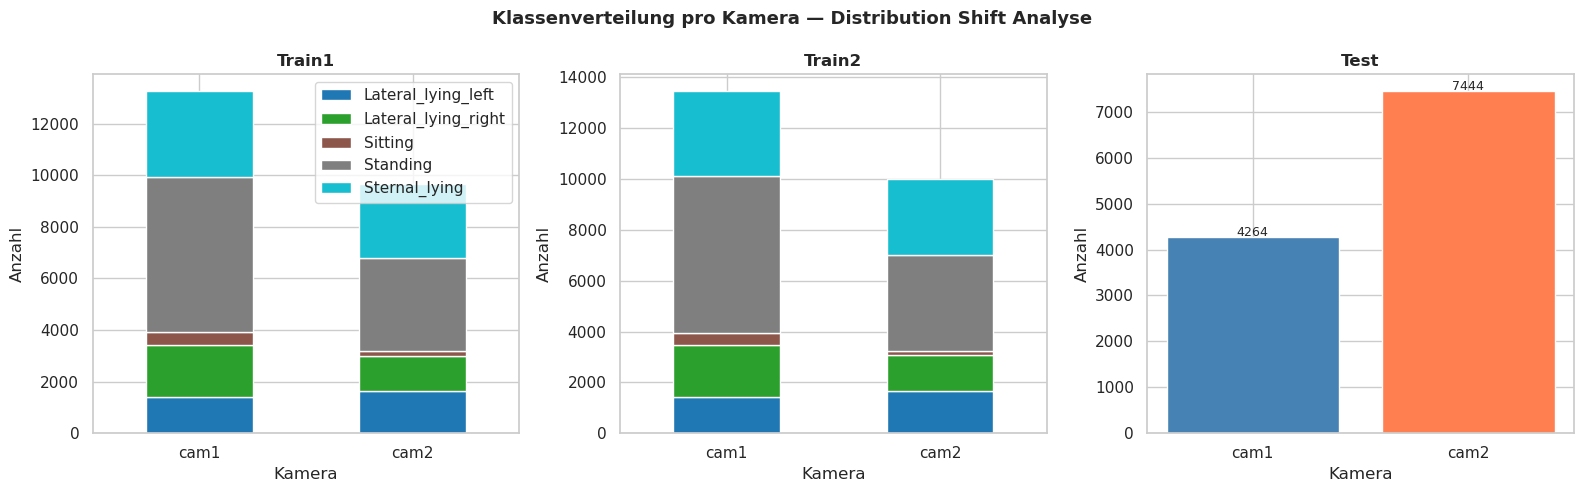


→ Train: ~58% cam1 / 42% cam2
→ Test:  ~36% cam1 / 64% cam2
→ Der Shift liegt im Kamera-Verhältnis: Test ist cam2-dominiert!


In [8]:
print("=== Kamera-Verteilung ===")
for name, df in [("Train1", train1_df), ("Train2", train2_df), ("Test", test_df)]:
    cam_counts = df["camera"].value_counts().sort_index()
    print(f"\n{name}:")
    for cam, cnt in cam_counts.items():
        print(f"  {cam}: {cnt:>5} Samples ({cnt/len(df)*100:.1f}%)")

# Visualisierung
fig, axes = plt.subplots(1, 3, figsize=(16, 5))

for ax, (name, df) in zip(axes, [("Train1", train1_df), ("Train2", train2_df), ("Test", test_df)]):
    if "class_id" in df.columns:
        cam_class = df.groupby(["camera", "class_id"]).size().unstack(fill_value=0)
        cam_class.columns = [CLASS_NAMES[c] for c in cam_class.columns]
        cam_class.plot(kind="bar", stacked=True, ax=ax, colormap="tab10", legend=(name == "Train1"))
    else:
        cam_counts = df["camera"].value_counts().sort_index()
        ax.bar(cam_counts.index, cam_counts.values, color=["steelblue", "coral"])
        for cam, cnt in cam_counts.items():
            ax.text(cam, cnt + 30, str(cnt), ha="center", fontsize=9)
    ax.set_title(f"{name}", fontweight="bold")
    ax.set_xlabel("Kamera")
    ax.set_ylabel("Anzahl")
    ax.tick_params(axis="x", rotation=0)

plt.suptitle("Klassenverteilung pro Kamera — Distribution Shift Analyse", fontsize=13, fontweight="bold")
plt.tight_layout()
plt.show()

print("\n→ Train: ~58% cam1 / 42% cam2")
print("→ Test:  ~36% cam1 / 64% cam2")
print("→ Der Shift liegt im Kamera-Verhältnis: Test ist cam2-dominiert!")

## 6. Zusammenfassung der EDA-Erkenntnisse

In [9]:
print("=" * 65)
print("ZUSAMMENFASSUNG DER EDA-ERKENNTNISSE")
print("=" * 65)

print(f"""
1. DATENSATZGRÖSSE
   Train1: {len(train1_df)} Samples | Train2: {len(train2_df)} Samples | Test: {len(test_df)} Samples
   Train2 ist der größere und für T2-Aufgabe relevantere Datensatz.

2. KLASSENIMBALANCE  →  kritisch für Macro F1!
   Imbalance-Ratio Train2: {ratio_t2:.1f}x  (Klasse 3 Standing vs. Klasse 2 Sitting)
   Klasse 2 (Sitting) ist mit nur ~3% stark unterrepräsentiert.
   Konsequenz: WeightedRandomSampler + class-weighted Loss notwendig.
   Macro F1 bestraft schlechte Performance auf Klasse 2 genauso stark
   wie auf der häufigsten Klasse.

3. DISTRIBUTION SHIFT
   Alle Datensätze nutzen hauptsächlich dieselbe Auflösung.
   Train und Test haben dieselben Kameras (cam1, cam2) — aber in
   unterschiedlichem Verhältnis:
     Train: ~58% cam1 / 42% cam2
     Test:  ~36% cam1 / 64% cam2
   Das Modell muss besonders gut auf cam2-Perspektiven generalisieren.
   Konsequenz: kamerabasiertes Training (je Modell pro Kamera) sinnvoll.

4. BOUNDING BOXES
   Liegende Schweine haben höheren Aspect Ratio (breiter als hoch):
     Lateral_lying: ~1.34  |  Sternal_lying: ~1.26
     Sitting: ~1.07        |  Standing: ~1.02
   Konsequenz: Bbox-Crop mit leichtem Padding sinnvoll für Kontext.
   Modell kann geometrische Form als implizites Signal nutzen.

5. VISUELLE ANALYSE (Klasse × Kamera)
   Cam1 und cam2 zeigen teils deutlich verschiedene Perspektiven
   (Vogelperspektive vs. schräg). Dies erklärt den Distribution Shift
   trotz gleicher Kamera-IDs.
""")

ZUSAMMENFASSUNG DER EDA-ERKENNTNISSE

1. DATENSATZGRÖSSE
   Train1: 22934 Samples | Train2: 23450 Samples | Test: 11708 Samples
   Train2 ist der größere und für T2-Aufgabe relevantere Datensatz.

2. KLASSENIMBALANCE  →  kritisch für Macro F1!
   Imbalance-Ratio Train2: 14.3x  (Klasse 3 Standing vs. Klasse 2 Sitting)
   Klasse 2 (Sitting) ist mit nur ~3% stark unterrepräsentiert.
   Konsequenz: WeightedRandomSampler + class-weighted Loss notwendig.
   Macro F1 bestraft schlechte Performance auf Klasse 2 genauso stark
   wie auf der häufigsten Klasse.

3. DISTRIBUTION SHIFT
   Alle Datensätze nutzen hauptsächlich dieselbe Auflösung.
   Train und Test haben dieselben Kameras (cam1, cam2) — aber in
   unterschiedlichem Verhältnis:
     Train: ~58% cam1 / 42% cam2
     Test:  ~36% cam1 / 64% cam2
   Das Modell muss besonders gut auf cam2-Perspektiven generalisieren.
   Konsequenz: kamerabasiertes Training (je Modell pro Kamera) sinnvoll.

4. BOUNDING BOXES
   Liegende Schweine haben höhere